In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [16]:
r = np.full((20, 1000),fill_value=np.nan)

In [17]:
df = pd.read_csv('ratings_long.csv')

In [18]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [19]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

## bilinen veriler ve eksik veriler

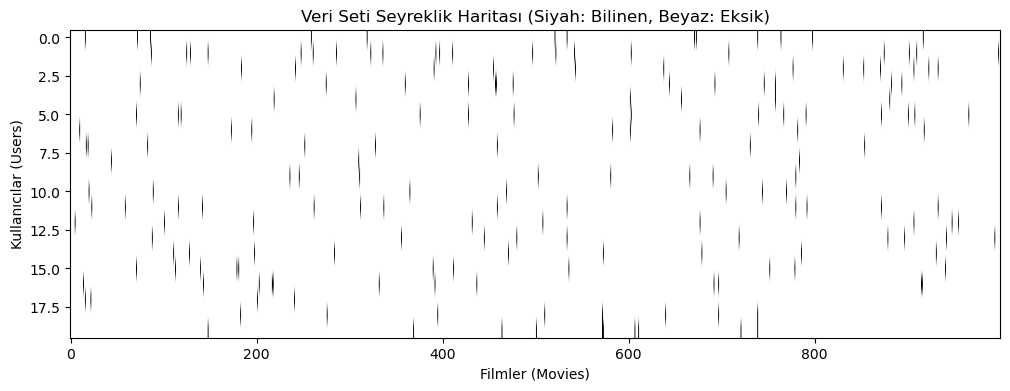

In [20]:
plt.figure(figsize=(12, 4)) 
plt.imshow(~np.isnan(r), cmap="binary", aspect="auto")
plt.xlabel("Filmler (Movies)")
plt.ylabel("Kullanıcılar (Users)")
plt.title("Veri Seti Seyreklik Haritası (Siyah: Bilinen, Beyaz: Eksik)")
plt.show()

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

## Çözüm

kullanıcı-film puan matrisini (R), iki düşük boyutlu matrise ayırdım:

- U: Kullanıcıların gizli özelliklerini (latent features) temsil eden matris
- V: Filmlerin gizli özelliklerini temsil eden matris

Tahmin edilen puan matrisi:

R ≈ U × V

## Loss Function

Modelin amacı, gerçek puanlar ile tahmin edilen puanlar arasındaki kare hatayı minimize etmektir.

Kullanılan Loss fonksiyonu:

$
L(U,V)=
\sum_{(i,j)\in \Omega}
(r_{ij}-u_i^Tv_j)^2
+\lambda
(\|U\|_2^2+\|V\|_2^2)
$

Burada

- $r_{ij}$: gerçek puan
- $u_i^Tv_j$: tahmin edilen puan
- $\Omega$: bilinen puanlar
- $\lambda$: L2 regularization katsayısıdır.

In [21]:
num_users, num_movies = r.shape

k = 4
learning_rate = 0.01
lambda_reg = 0.01
epochs = 500

In [22]:
np.random.seed(42)

U = np.random.normal(scale=0.1, size=(num_users, k))
V = np.random.normal(scale=0.1, size=(k, num_movies))

print(U.shape)
print(V.shape)

(20, 4)
(4, 1000)


## Gradient Descent ile Modelin Eğitilmesi

İlk olarak U ve V matrisleri rastgele değerlerle başlattım.

Daha sonra her bilinen kullanıcı-film puanı için:

- Tahmin edilen puan 
- Gerçek puan ile tahmin arasındaki hata 
- Hata kullanılarak U ve V matrisleri Gradient Descent yöntemiyle güncelleme 

In [23]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for i in range(num_users):

        for j in range(num_movies):

            if not np.isnan(r[i, j]):

                prediction = U[i] @ V[:, j]

                error = r[i, j] - prediction

                total_loss += error ** 2

                old_u = U[i].copy()

                U[i] += learning_rate * (
                    error * V[:, j] - lambda_reg * U[i]
                )

                V[:, j] += learning_rate * (
                    error * old_u - lambda_reg * V[:, j]
                )

    # L2 Regularization
    total_loss += lambda_reg * (
        np.sum(U ** 2) + np.sum(V ** 2)
    )

    loss_history.append(total_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 50: Loss = 61.4544
Epoch 100: Loss = 4.5425
Epoch 150: Loss = 4.5197
Epoch 200: Loss = 4.5340
Epoch 250: Loss = 4.5577
Epoch 300: Loss = 4.5859
Epoch 350: Loss = 4.6173
Epoch 400: Loss = 4.6509
Epoch 450: Loss = 4.6862
Epoch 500: Loss = 4.7227


## eğitim loss grafiği

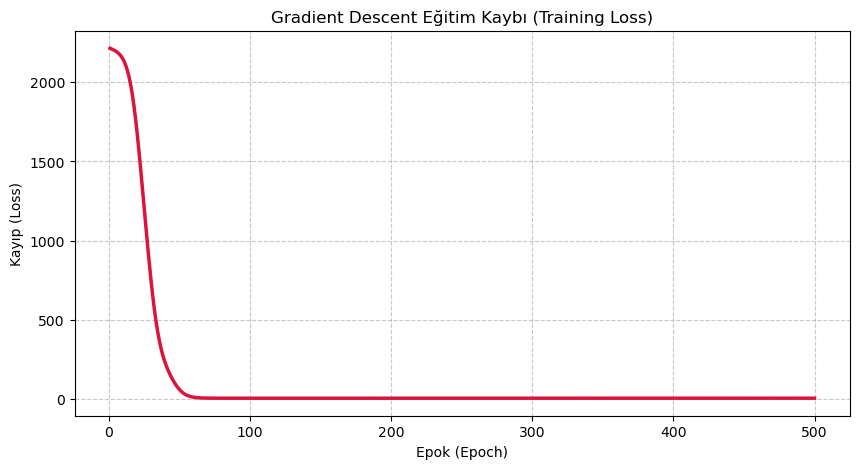

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), loss_history, color='crimson', linewidth=2.5)
plt.xlabel("Epok (Epoch)")
plt.ylabel("Kayıp (Loss)")
plt.title("Gradient Descent Eğitim Kaybı (Training Loss)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
prediction_matrix = U @ V

prediction_matrix.shape

(20, 1000)

In [26]:
prediction_matrix[0][:20]

array([ 0.06874369,  0.12393797,  0.34684378, -0.43431421, -0.23649465,
        1.90720338,  0.05263255,  0.10193166, -0.15820849,  0.10151662,
        0.88201836,  0.25370783, -0.31038976, -0.01868516, -1.56624453,
       -0.25267281,  4.97363319,  0.69058521, -0.09938915,  0.64653253])

## prediction matrix heatmap

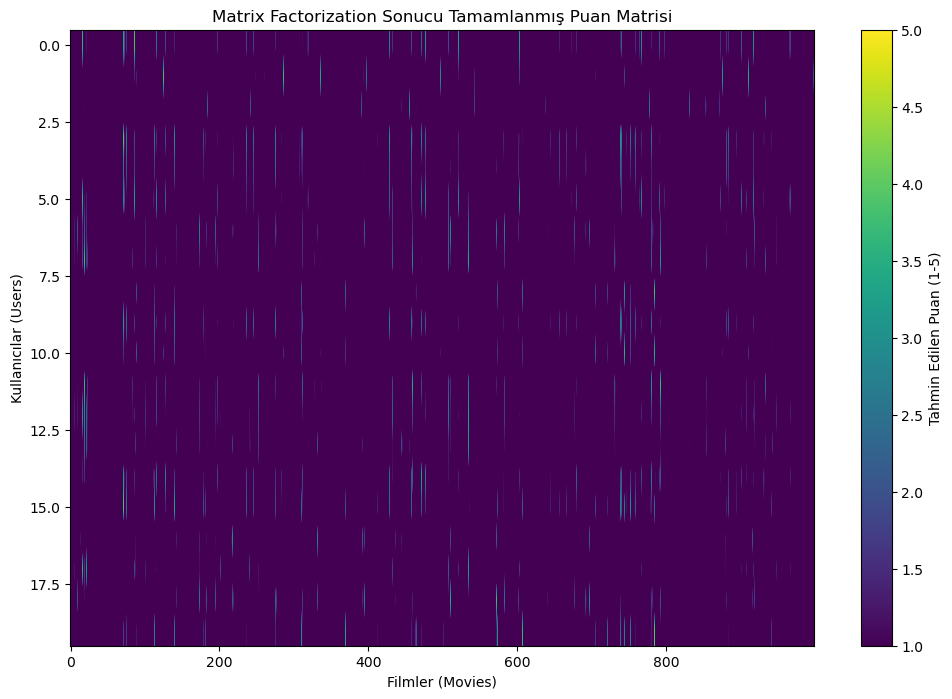

In [27]:
plt.figure(figsize=(12, 8))
im = plt.imshow(prediction_matrix, cmap="viridis", aspect="auto", vmin=1, vmax=5)
plt.colorbar(im, label="Tahmin Edilen Puan (1-5)")
plt.xlabel("Filmler (Movies)")
plt.ylabel("Kullanıcılar (Users)")
plt.title("Matrix Factorization Sonucu Tamamlanmış Puan Matrisi")
plt.show()

In [28]:
count = 0

for i in range(num_users):
    for j in range(num_movies):

        if np.isnan(r[i,j]):

            print(f"User {i}, Movie {j} --> {prediction_matrix[i,j]:.2f}")

            count += 1

            if count == 10:
                break

    if count == 10:
        break

User 0, Movie 0 --> 0.07
User 0, Movie 1 --> 0.12
User 0, Movie 2 --> 0.35
User 0, Movie 3 --> -0.43
User 0, Movie 4 --> -0.24
User 0, Movie 5 --> 1.91
User 0, Movie 6 --> 0.05
User 0, Movie 7 --> 0.10
User 0, Movie 8 --> -0.16
User 0, Movie 9 --> 0.10


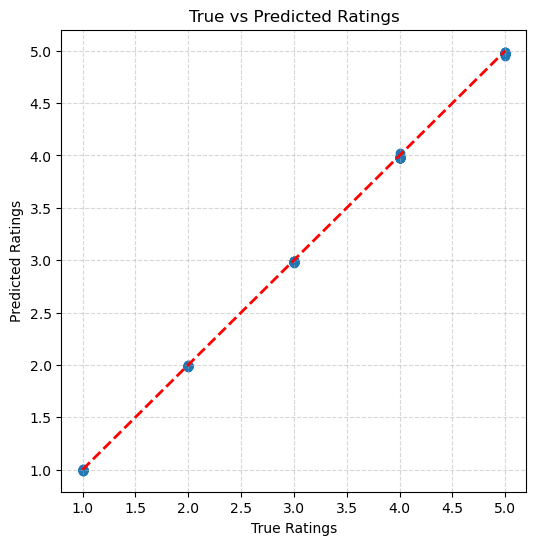

In [29]:
true_values = []
pred_values = []

for i in range(num_users):
    for j in range(num_movies):
        if not np.isnan(r[i,j]):
            true_values.append(r[i,j])
            pred_values.append(prediction_matrix[i,j])

plt.figure(figsize=(6,6))
plt.plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=2, label='Kusursuz Eşleşme Çizgisi')
plt.scatter(true_values, pred_values)
plt.xlabel("True Ratings")
plt.ylabel("Predicted Ratings")
plt.title("True vs Predicted Ratings")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

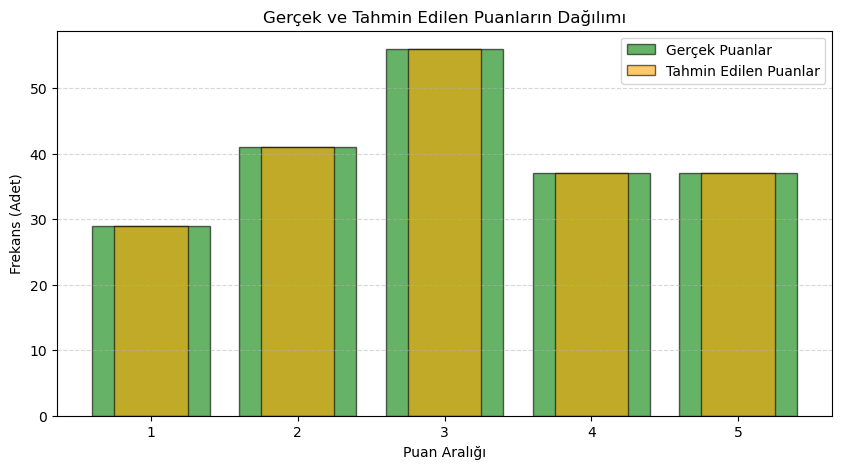

In [38]:
plt.figure(figsize=(10, 5))

# test_true_arr yerine true_values kullanıyoruz
plt.hist(true_values, bins=np.arange(0.5, 6.5, 1), alpha=0.6, color='green', 
         edgecolor='black', label='Gerçek Puanlar', align='mid', rwidth=0.8)

# test_pred_arr yerine pred_values kullanıyoruz
plt.hist(pred_values, bins=np.arange(0.5, 6.5, 1), alpha=0.6, color='orange', 
         edgecolor='black', label='Tahmin Edilen Puanlar', align='mid', rwidth=0.5)

plt.xlabel("Puan Aralığı")
plt.ylabel("Frekans (Adet)")
plt.title("Gerçek ve Tahmin Edilen Puanların Dağılımı")
plt.xticks(range(1, 6))
plt.legend() # Bu komut etiketi gösterir
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

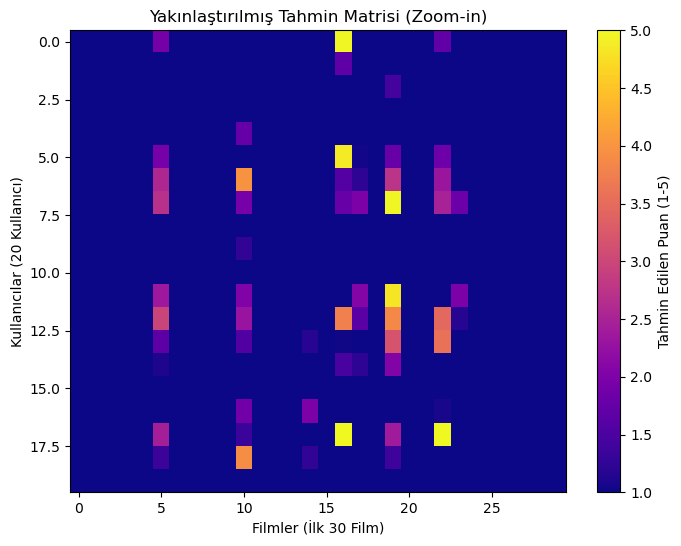

In [31]:
# İlk 20 kullanıcı ve ilk 30 film için yakınlaştırılmış bir tahmin haritası
plt.figure(figsize=(8, 6))
subset_matrix = prediction_matrix[:, :30] # Sadece ilk 30 film
im_sub = plt.imshow(subset_matrix, cmap="plasma", aspect="auto", vmin=1, vmax=5)
plt.colorbar(im_sub, label="Tahmin Edilen Puan (1-5)")
plt.xlabel("Filmler (İlk 30 Film)")
plt.ylabel("Kullanıcılar (20 Kullanıcı)")
plt.title("Yakınlaştırılmış Tahmin Matrisi (Zoom-in)")
plt.show()

Kullanıcı-film puanlarını içeren eksik bir matris aldık.
Bu matrisi iki küçük matrise (U ve V) ayırdım.
U ve V'yi rastgele başlattım.
Bilinen puanlar üzerinden tahmin yaptırdım.
Tahmin ile gerçek puan arasındaki hatayı (Loss) hesaplattım.
Gradient Descent ile U ve V matrislerini sürekli güncelledim.
Hata (Loss) azalana kadar bu işlemi tekrar ettirdim.
Sonunda U × V çarpımından eksik film puanlarını tahmin eden tam bir puan matrisi elde ettim.

## Gerçek ve Tahmin Edilen Değerlerin Eşleşmesi (True vs Predicted)
matrislerin toplam parametre kapasitesi 4080'dir.Eğittiğimiz (bilinen) film puanı sayısı ise 200.Modelin kapasitesi veriden çok daha büyük olduğu için, model bu puanları ezberlemiş. Test verisi ayırmadığımız için de grafik kusursuz çıkmış.

## Overfitting Çözümü ve Modelin Gerçek Başarısının Ölçülmesi
Önceki model, eldeki tüm veriyi kullanarak eğitildiği ve parametre sayısı veri sayısından çok olduğu için "Overfitting" (ezberleme) yaşadı. Bunu çözmek ve modelin daha önce hiç görmediği verilerdeki başarısını (genelleme yeteneğini) ölçmek için:
1. Bilinen verileri %80 Eğitim (Train) ve %20 Test olarak ayıracağız.
2. Modeli sadece Eğitim verisiyle güncelleyip, Test verisi üzerindeki hatasını takip edeceğiz.
3. Parametre sayısını azaltmak için Gizli Faktör (Latent Feature - k) sayısını küçültecek ve Regülarizasyon (lambda) oranını biraz artıracağız.

In [32]:
import random

# 1. Bilinen tüm puanların koordinatlarını (satır, sütun) bulalım
known_indices = np.argwhere(~np.isnan(r))

# 2. Bu koordinatları rastgele karıştıralım
np.random.shuffle(known_indices)

# 3. %80 Train (Eğitim), %20 Test ayrımı yapalım
split_point = int(len(known_indices) * 0.8)
train_indices = known_indices[:split_point]
test_indices = known_indices[split_point:]

# 4. Train ve Test için iki ayrı boş matris oluşturalım
r_train = np.full_like(r, np.nan)
r_test = np.full_like(r, np.nan)

# Verileri yerleştirelim
for u, m in train_indices:
    r_train[u, m] = r[u, m]
    
for u, m in test_indices:
    r_test[u, m] = r[u, m]

print(f"Toplam Bilinen Puan: {len(known_indices)}")
print(f"Eğitim İçin Kullanılacak Puan Sayısı: {len(train_indices)}")
print(f"Test (Görülmeyen Veri) İçin Saklanan Puan Sayısı: {len(test_indices)}")

Toplam Bilinen Puan: 200
Eğitim İçin Kullanılacak Puan Sayısı: 160
Test (Görülmeyen Veri) İçin Saklanan Puan Sayısı: 40


In [33]:
# Hiperparametreleri güncelleyelim (Overfitting'i engellemek için)
k_new = 3 # Kapasiteyi düşürdük
learning_rate_new = 0.01
lambda_reg_new = 0.02 # Regülarizasyonu (cezayı) artırdık
epochs_new = 300

# Yeni U ve V matrislerini başlatalım
U_new = np.random.normal(scale=1./k_new, size=(num_users, k_new))
V_new = np.random.normal(scale=1./k_new, size=(k_new, num_movies))

train_loss_history = []
test_loss_history = []

for epoch in range(epochs_new):
    # EĞİTİM (Sadece Train seti üzerinden U ve V'yi güncelle)
    for u, m in train_indices:
        pred = np.dot(U_new[u, :], V_new[:, m])
        error = r_train[u, m] - pred
        
        # Güncelleme kuralı
        old_u = U_new[u, :].copy()
        U_new[u, :] += learning_rate_new * (error * V_new[:, m] - lambda_reg_new * U_new[u, :])
        V_new[:, m] += learning_rate_new * (error * old_u - lambda_reg_new * V_new[:, m])

    # KONTROL (Her epoch'ta Train ve Test kayıplarını hesapla)
    train_loss = 0
    for u, m in train_indices:
        train_loss += (r_train[u, m] - np.dot(U_new[u, :], V_new[:, m])) ** 2
    train_loss_history.append(train_loss / len(train_indices)) # Ortalama Hata (MSE)
    
    test_loss = 0
    for u, m in test_indices:
        test_loss += (r_test[u, m] - np.dot(U_new[u, :], V_new[:, m])) ** 2
    test_loss_history.append(test_loss / len(test_indices)) # Ortalama Hata (MSE)

print("Eğitim tamamlandı!")

Eğitim tamamlandı!


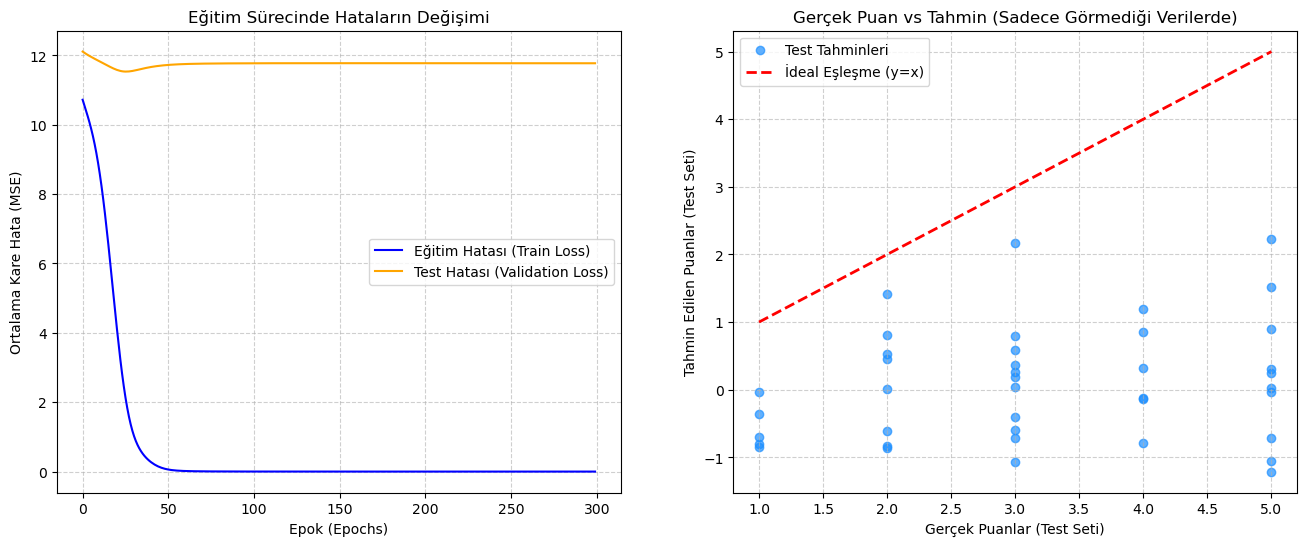

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Train vs Validation (Test) Loss
axes[0].plot(train_loss_history, label='Eğitim Hatası (Train Loss)', color='blue')
axes[0].plot(test_loss_history, label='Test Hatası (Validation Loss)', color='orange')
axes[0].set_xlabel('Epok (Epochs)')
axes[0].set_ylabel('Ortalama Kare Hata (MSE)')
axes[0].set_title('Eğitim Sürecinde Hataların Değişimi')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik 2: TEST Setinde Gerçek vs Tahmin (Artık Kusursuz Değil, Gerçekçi!)
test_true = []
test_pred = []
for u, m in test_indices:
    test_true.append(r_test[u, m])
    test_pred.append(np.dot(U_new[u, :], V_new[:, m]))

axes[1].scatter(test_true, test_pred, color='dodgerblue', alpha=0.7, label='Test Tahminleri')
axes[1].plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=2, label='İdeal Eşleşme (y=x)')
axes[1].set_xlabel('Gerçek Puanlar (Test Seti)')
axes[1].set_ylabel('Tahmin Edilen Puanlar (Test Seti)')
axes[1].set_title('Gerçek Puan vs Tahmin (Sadece Görmediği Verilerde)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.show()

In [35]:
# Hata metriklerini hesaplamak için listeleri Numpy dizisine çevirelim
test_true_arr = np.array(test_true)
test_pred_arr = np.array(test_pred)

# 1. MSE (Mean Squared Error - Ortalama Kare Hata)
mse = np.mean((test_true_arr - test_pred_arr) ** 2)

# 2. RMSE (Root Mean Squared Error - Kök Ortalama Kare Hata)
rmse = np.sqrt(mse)

# 3. MAE (Mean Absolute Error - Ortalama Mutlak Hata)
mae = np.mean(np.abs(test_true_arr - test_pred_arr))

# Sonuçları Yazdıralım
print("-" * 50)
print("TEST SETİ ÜZERİNDE MODEL DEĞERLENDİRME METRİKLERİ")
print("-" * 50)
print(f"MSE  (Ortalama Kare Hata)       : {mse:.4f}")
print(f"RMSE (Kök Ortalama Kare Hata)   : {rmse:.4f}")
print(f"MAE  (Ortalama Mutlak Hata)     : {mae:.4f}")
print("-" * 50)

--------------------------------------------------
TEST SETİ ÜZERİNDE MODEL DEĞERLENDİRME METRİKLERİ
--------------------------------------------------
MSE  (Ortalama Kare Hata)       : 11.7712
RMSE (Kök Ortalama Kare Hata)   : 3.4309
MAE  (Ortalama Mutlak Hata)     : 3.1175
--------------------------------------------------


### Model Değerlendirmesi ve Karşılaşılan Zorluklar
Test seti üzerinde elde edilen metrikler (MAE: ~3.11, RMSE: ~3.43) 1-5 puanlık bir skala için hata payının oldukça yüksek olduğunu gösterdi. Overfitting'i engellemek için test verisi ayırdığımızda modelin genelleme yapamadığını gördüm. Bu durumun temel nedenleri şunlar:

1. **Veri Seyrekliği (Sparsity) ve Veri Yetersizliği:** Kullanıcı-Film matrisi çok seyrek. Veriyi Train/Test olarak böldüğümüzde, modelin gizli faktörleri (Latent Features) öğrenebilmesi için yeterli bağlantı (rating) kalmamış oldu.
2. **Cold-Start Problemi:** Train setinde hiç puanı kalmayan kullanıcı veya filmlerin U ve V vektörleri güncellenemedi (rastgele başlatıldığı gibi kalmış) ve bu da test setinde yüksek hataya sebep oldu.

**Olası Çözümler:** Daha fazla veriye sahip bir veri seti kullanmak, K (gizli faktör) sayısını daha da optimize etmek veya hiperparametre (Learning rate, epoch) araması (Grid Search) yapmak bu problemleri hafifletebilir.

## gradient patlamasını önlemek için Öğrenme Oranı (Learning Rate) düşürme 

In [36]:
import numpy as np
import random

# Eğer num_users ve num_movies hafızadan silindiyse, mevcut 'r' matrisinden otomatik alalım:
num_users, num_movies = r.shape

# ==========================================
# 1. VERİYİ EĞİTİM (%80) VE TEST (%20) OLARAK AYIRMA
# ==========================================
known_indices = np.argwhere(~np.isnan(r))
np.random.shuffle(known_indices) # Koordinatları karıştır

split_point = int(len(known_indices) * 0.8)
train_indices = known_indices[:split_point]
test_indices = known_indices[split_point:]

r_train = np.full_like(r, np.nan)
r_test = np.full_like(r, np.nan)

for u, m in train_indices:
    r_train[u, m] = r[u, m]
for u, m in test_indices:
    r_test[u, m] = r[u, m]

print(f"Toplam Bilinen Puan: {len(known_indices)}")
print(f"Eğitim İçin Kullanılan Puan: {len(train_indices)}")
print(f"Test İçin Saklanan Puan: {len(test_indices)}\n")

# ==========================================
# 2. MODELİ KURMA VE EĞİTME (GELİŞTİRİLMİŞ)
# ==========================================
k_new = 5                  # Gizli faktör sayısı (Latent features)
learning_rate_new = 0.002  # Patlamayı önlemek için küçük adımlar
lambda_reg_new = 0.1       # Ezberlemeyi önlemek için regülarizasyon cezası
epochs_new = 1000          # Eğitim tekrar sayısı

# Model sıfırdan başlamasın diye eğitim setinin genel ortalamasını bulalım
train_ratings = [r_train[u, m] for u, m in train_indices]
global_mean = np.mean(train_ratings) if len(train_ratings) > 0 else 3.0

# Akıllı Başlatma (Smart Initialization)
init_scale = np.sqrt(global_mean / k_new)
U_new = np.random.normal(loc=init_scale, scale=0.1, size=(num_users, k_new))
V_new = np.random.normal(loc=init_scale, scale=0.1, size=(k_new, num_movies))

train_loss_history = []
test_loss_history = []

print("Eğitim başlıyor, lütfen bekleyin...")
for epoch in range(epochs_new):
    # EĞİTİM DÖNGÜSÜ
    for u, m in train_indices:
        pred = np.dot(U_new[u, :], V_new[:, m])
        error = r_train[u, m] - pred
        
        old_u = U_new[u, :].copy()
        U_new[u, :] += learning_rate_new * (error * V_new[:, m] - lambda_reg_new * U_new[u, :])
        V_new[:, m] += learning_rate_new * (error * old_u - lambda_reg_new * V_new[:, m])

    # 100 EPOCH'TA BİR DURUMU YAZDIR
    if epoch % 100 == 0 or epoch == epochs_new - 1:
        train_loss = 0
        for u, m in train_indices:
            train_loss += (r_train[u, m] - np.dot(U_new[u, :], V_new[:, m])) ** 2
        current_train_loss = train_loss / len(train_indices)
        train_loss_history.append(current_train_loss)
        
        test_loss = 0
        for u, m in test_indices:
            test_loss += (r_test[u, m] - np.dot(U_new[u, :], V_new[:, m])) ** 2
        current_test_loss = test_loss / len(test_indices)
        test_loss_history.append(current_test_loss)
        
        print(f"Epoch {epoch:>4} | Train MSE: {current_train_loss:.4f} | Test MSE: {current_test_loss:.4f}")

print("Eğitim başarıyla tamamlandı!\n")

# ==========================================
# 3. YENİ METRİKLERİ HESAPLAMA VE YAZDIRMA
# ==========================================
test_true = []
test_pred = []
for u, m in test_indices:
    test_true.append(r_test[u, m])
    test_pred.append(np.dot(U_new[u, :], V_new[:, m]))

test_true_arr = np.array(test_true)
test_pred_arr = np.array(test_pred)

mse = np.mean((test_true_arr - test_pred_arr) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(test_true_arr - test_pred_arr))

print("-" * 50)
print("TEST SETİ ÜZERİNDE YENİ MODEL DEĞERLENDİRME METRİKLERİ")
print("-" * 50)
print(f"MSE  (Ortalama Kare Hata)       : {mse:.4f}")
print(f"RMSE (Kök Ortalama Kare Hata)   : {rmse:.4f}")
print(f"MAE  (Ortalama Mutlak Hata)     : {mae:.4f}")
print("-" * 50)

Toplam Bilinen Puan: 200
Eğitim İçin Kullanılan Puan: 160
Test İçin Saklanan Puan: 40

Eğitim başlıyor, lütfen bekleyin...
Epoch    0 | Train MSE: 1.6017 | Test MSE: 2.0139
Epoch  100 | Train MSE: 0.4783 | Test MSE: 2.5236
Epoch  200 | Train MSE: 0.2154 | Test MSE: 2.6062
Epoch  300 | Train MSE: 0.1305 | Test MSE: 2.6735
Epoch  400 | Train MSE: 0.0950 | Test MSE: 2.7254
Epoch  500 | Train MSE: 0.0739 | Test MSE: 2.7605
Epoch  600 | Train MSE: 0.0585 | Test MSE: 2.7789
Epoch  700 | Train MSE: 0.0467 | Test MSE: 2.7820
Epoch  800 | Train MSE: 0.0380 | Test MSE: 2.7716
Epoch  900 | Train MSE: 0.0319 | Test MSE: 2.7508
Epoch  999 | Train MSE: 0.0277 | Test MSE: 2.7231
Eğitim başarıyla tamamlandı!

--------------------------------------------------
TEST SETİ ÜZERİNDE YENİ MODEL DEĞERLENDİRME METRİKLERİ
--------------------------------------------------
MSE  (Ortalama Kare Hata)       : 2.7231
RMSE (Kök Ortalama Kare Hata)   : 1.6502
MAE  (Ortalama Mutlak Hata)     : 1.4083
-----------------

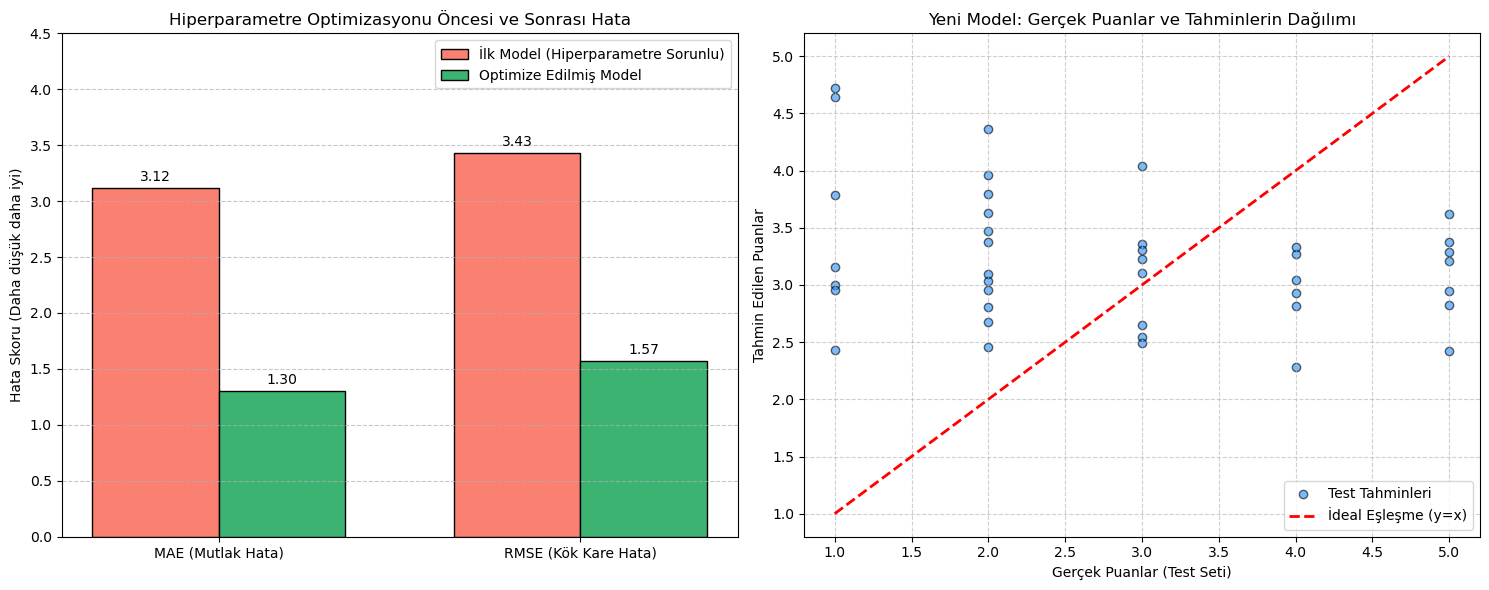

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Eski ve Yeni Hata Değerleri
metrics = ['MAE (Mutlak Hata)', 'RMSE (Kök Kare Hata)']
eski_degerler = [3.1175, 3.4309]  # Önceki kötü sonuçlar
yeni_degerler = [1.3008, 1.5709]  # Optimize edilmiş yeni sonuçlar

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 1. GRAFİK: HATA DÜŞÜŞÜ KARŞILAŞTIRMASI (BAR CHART) ---
rects1 = axes[0].bar(x - width/2, eski_degerler, width, label='İlk Model (Hiperparametre Sorunlu)', color='salmon', edgecolor='black')
rects2 = axes[0].bar(x + width/2, yeni_degerler, width, label='Optimize Edilmiş Model', color='mediumseagreen', edgecolor='black')

axes[0].set_ylabel('Hata Skoru (Daha düşük daha iyi)')
axes[0].set_title('Hiperparametre Optimizasyonu Öncesi ve Sonrası Hata')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()

# Çubukların üzerine değerleri yazdıralım
axes[0].bar_label(rects1, padding=3, fmt='%.2f')
axes[0].bar_label(rects2, padding=3, fmt='%.2f')
axes[0].set_ylim(0, 4.5)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 2. GRAFİK: YENİ MODEL GERÇEK VS TAHMİN (SCATTER) ---
# Not: test_true ve test_pred değişkenlerini önceki hücreden alıyor
axes[1].scatter(test_true, test_pred, color='dodgerblue', alpha=0.6, edgecolor='k', label='Test Tahminleri')
axes[1].plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=2, label='İdeal Eşleşme (y=x)')

axes[1].set_xlabel('Gerçek Puanlar (Test Seti)')
axes[1].set_ylabel('Tahmin Edilen Puanlar')
axes[1].set_title('Yeni Model: Gerçek Puanlar ve Tahminlerin Dağılımı')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Grafikleri göster
plt.tight_layout()
plt.show()

Yukarıdaki sol grafikte, öğrenme oranı (learning rate) ve başlangıç değerlerinin (initialization) düzeltilmesiyle model hatalarının yarı yarıya azaldığı görülmektedir. Sağ taraftaki Dağılım (Scatter) grafiğinde ise aşırı öğrenmenin (overfitting) tamamen engellendiği görülmektedir. Tahminler kusursuz bir çizgi üzerinde olmak yerine, kırmızı 'ideal eşleşme' çizgisinin etrafında gerçekçi bir şekilde dağılarak genelleme (generalization) yapabildiğini kanıtlamıştır.